In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from glob import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as sk

import thicket as tt

Set of kernels for each machine and tuning combination. Defined from manual analysis.

In [2]:
ddr_topdown_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    "funcptr": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
}

In [3]:
ddr_no_topdown_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    "funcptr": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
}

In [4]:
hbm_topdown_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    "funcptr": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
}

In [5]:
hbm_no_topdown_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    "funcptr": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr
}

In [6]:
v100_kernels = {
    "block_256": [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    "default": [
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
    ], # For default
    "blkatm_occgs_256": [
        "Algorithm_REDUCE_SUM",
        "Basic_PI_REDUCE",
        "Basic_REDUCE3_INT",
        "Basic_REDUCE_STRUCT",
        "Basic_TRAP_INT",
        "Stream_DOT",
    ], # For blkatm_occgs_256
    "block_64": [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    "block_25": [
        "Apps_MASS3DPA",
    ], # For block_25
    "funcptr_256": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr_256
    "cub": [
        "Algorithm_SCAN",
    ], # For cub
    "atomic_occgs_256": [
        "Algorithm_HISTOGRAM",
        "Basic_MULTI_REDUCE",
    ], # For atomic_occgs_256
    "blkdev_occgs_256": [
        "Lcals_FIRST_MIN",
    ], # For blkdev_occgs_256
}

In [7]:
mi250x_kernels = {
    "block_256": [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    "default": [
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
    ], # For default
    "blkatm_occgs_256": [
        "Algorithm_REDUCE_SUM",
        "Basic_PI_REDUCE",
        "Basic_REDUCE3_INT",
        "Basic_REDUCE_STRUCT",
        "Basic_TRAP_INT",
        "Stream_DOT",
    ], # For blkatm_occgs_256
    "block_64": [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    "block_25": [
        "Apps_MASS3DPA",
    ], # For block_25
    "funcptr_256": [
        "Comm_HALO_EXCHANGE_FUSED",
        "Comm_HALO_PACKING_FUSED",
    ], # For funcptr_256
    "rocprim": [
        "Algorithm_SCAN",
    ], # For rocprim
    "atomic_occgs_256": [
        "Algorithm_HISTOGRAM",
        "Basic_MULTI_REDUCE",
    ], # For atomic_occgs_256
    "blkdev_occgs_256": [
        "Lcals_FIRST_MIN",
    ], # For blkdev_occgs_256
}

In [8]:
# Kernels to exclude, agnostic of parameters
exclude_kernels = [
    "Algorithm_ATOMIC",
    "Basic_INDEXLIST",
    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_SENDRECV",
]

Queries used to match kernel names

In [9]:
def kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n in kernel_list
        ).all()
    ).rel("*")

def not_kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n not in kernel_list
        ).all()
    ).rel("*")

Setup directory paths and read profiles into Thicket

In [10]:
# Directories
main_dir = "../data/topdown_metrics/"
epyc_mi250x_dir = main_dir + "epyc-mi250x/"
p9_v100_dir = main_dir + "p9-v100/"
spr_ddr_dir = main_dir + "spr-ddr/"
spr_hbm_dir = main_dir + "spr-hbm/"

tk_mi250x = tt.Thicket.from_caliperreader(glob(epyc_mi250x_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_v100 = tt.Thicket.from_caliperreader(glob(p9_v100_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_spr_ddr = tt.Thicket.from_caliperreader(glob(spr_ddr_dir + "**/*.cali", recursive=True), fill_perfdata=False)
tk_spr_hbm = tt.Thicket.from_caliperreader(glob(spr_hbm_dir + "**/*.cali", recursive=True), fill_perfdata=False)

print("epyc-mi250x: ", len(tk_mi250x.profile), " files")
print("p9-v100: ", len(tk_v100.profile), " files")
print("spr-ddr: ", len(tk_spr_ddr.profile), " files")
print("spr-hbm: ", len(tk_spr_hbm.profile), " files")

(2/2) Creating Thicket: 100%|██████████| 39/39 [00:00<00:00, 58.30it/s]

epyc-mi250x:  90  files
p9-v100:  90  files
spr-ddr:  40  files
spr-hbm:  40  files


Groupby variant, tuning, and topdown configuration to enable applying the kernel selection from the dictionaries we defined above.

In [11]:
gb_params = ["variant", "tuning"]
gb_mi250x = tk_mi250x.groupby(gb_params)
gb_v100 = tk_v100.groupby(gb_params)
gb_spr_ddr = tk_spr_ddr.groupby(gb_params+["spot:topdown.all"])
gb_spr_hbm = tk_spr_hbm.groupby(gb_params+["spot:topdown.all"])

Apply queries to select specific kernels from data

In [12]:
new_gb_mi250x = {}
new_gb_v100 = {}
gb_spr_ddr_topdown = {}
gb_spr_ddr_notopdown = {}
gb_spr_hbm_topdown = {}
gb_spr_hbm_notopdown = {}

print("mi250x")
for k in gb_mi250x.keys():
    print("\t", k)
    new_gb_mi250x[k] = gb_mi250x[k].query(kernel_query(mi250x_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
    
print("v100")
for k in gb_v100.keys():
    if k[1] not in v100_kernels.keys():
        print("\tSkipping ", k)
        continue
    print("\t", k)
    new_gb_v100[k] = gb_v100[k].query(kernel_query(v100_kernels[k[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

print("spr-ddr")
for key in gb_spr_ddr.keys():
    print("\t", key)
    if key[2] == 'true':
        gb_spr_ddr_topdown[key] = gb_spr_ddr[key].query(kernel_query(ddr_topdown_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
    else:
        gb_spr_ddr_notopdown[key] = gb_spr_ddr[key].query(kernel_query(ddr_no_topdown_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
print("spr-hbm")
for key in gb_spr_hbm.keys():
    print("\t", key)
    if key[2] == 'true':
        gb_spr_hbm_topdown[key] = gb_spr_hbm[key].query(kernel_query(hbm_topdown_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")
    else:
        gb_spr_hbm_notopdown[key] = gb_spr_hbm[key].query(kernel_query(hbm_no_topdown_kernels[key[1]]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

mi250x
	 ('RAJA_HIP', 'atomic_occgs_256')
	 ('RAJA_HIP', 'blkatm_occgs_256')
	 ('RAJA_HIP', 'blkdev_occgs_256')
	 ('RAJA_HIP', 'block_25')
	 ('RAJA_HIP', 'block_256')
	 ('RAJA_HIP', 'block_64')
	 ('RAJA_HIP', 'default')
	 ('RAJA_HIP', 'funcptr_256')
	 ('RAJA_HIP', 'rocprim')
v100
	 ('RAJA_CUDA', 'atomic_occgs_256')
	 ('RAJA_CUDA', 'blkatm_occgs_256')
	 ('RAJA_CUDA', 'blkdev_occgs_256')
	 ('RAJA_CUDA', 'block_25')
	 ('RAJA_CUDA', 'block_256')
	 ('RAJA_CUDA', 'block_64')
	 ('RAJA_CUDA', 'cub')
	 ('RAJA_CUDA', 'default')
	 ('RAJA_CUDA', 'funcptr_256')
spr-ddr
	 ('RAJA_Seq', 'default', 'true')
	 ('RAJA_Seq', 'default', nan)
	 ('RAJA_Seq', 'funcptr', 'true')
	 ('RAJA_Seq', 'funcptr', nan)
spr-hbm
	 ('RAJA_Seq', 'default', 'true')
	 ('RAJA_Seq', 'default', nan)
	 ('RAJA_Seq', 'funcptr', 'true')
	 ('RAJA_Seq', 'funcptr', nan)


TODO Section for manual composition

In [13]:
new_dicts = [
    new_gb_mi250x,
    new_gb_v100,
    gb_spr_ddr_topdown,
    gb_spr_ddr_notopdown,
    gb_spr_hbm_topdown,
    gb_spr_hbm_notopdown,
]

# TODO: manual composition operations
trials = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for dic in new_dicts:
    for k in dic.keys():
        dic[k].metadata["trials"] = trials
        dic[k].metadata_columns_to_perfdata("trials")
        dic[k].dataframe = dic[k].dataframe.reset_index().drop(columns="profile")
        dic[k].dataframe = dic[k].dataframe.rename(columns={"trials": "profile"})
        dic[k].dataframe = dic[k].dataframe.reset_index().set_index(["node","profile"])

        dic[k].profile =  trials

        dic[k].metadata = dic[k].metadata.reset_index().drop(columns="profile")
        dic[k].metadata = dic[k].metadata.rename(columns={"trials": "profile"})
        dic[k].metadata = dic[k].metadata.set_index("profile")

        assert len(dic[k].profile) == 10

In [14]:
tk_mi250x = tt.Thicket.concat_thickets(list(new_gb_mi250x.values()), fill_perfdata=False)
tk_v100 = tt.Thicket.concat_thickets(list(new_gb_v100.values()), fill_perfdata=False)
tk_spr_ddr_topdown = tt.Thicket.concat_thickets(list(gb_spr_ddr_topdown.values()), fill_perfdata=False)
tk_spr_ddr_notopdown = tt.Thicket.concat_thickets(list(gb_spr_ddr_notopdown.values()), fill_perfdata=False)
tk_spr_hbm_topdown = tt.Thicket.concat_thickets(list(gb_spr_hbm_topdown.values()), fill_perfdata=False)
tk_spr_hbm_notopdown = tt.Thicket.concat_thickets(list(gb_spr_hbm_notopdown.values()), fill_perfdata=False)

# TODO: Manually setting profile
tk_mi250x.profile = trials
tk_v100.profile = trials
tk_spr_ddr_topdown.profile = trials
tk_spr_ddr_notopdown.profile = trials
tk_spr_hbm_topdown.profile = trials
tk_spr_hbm_notopdown.profile = trials

In [15]:
# TODO: resetting profile mapping object
from collections import OrderedDict
tk_mi250x.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})
tk_v100.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})
tk_spr_ddr_topdown.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})
tk_spr_ddr_notopdown.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})
tk_spr_hbm_topdown.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})
tk_spr_hbm_notopdown.profile_mapping = OrderedDict({i: f"{i}.cali" for i in trials})

In [16]:
print(len(tk_mi250x.dataframe))
print(len(tk_v100.dataframe))
print(len(tk_spr_ddr_topdown.dataframe))
print(len(tk_spr_ddr_notopdown.dataframe))
print(len(tk_spr_hbm_topdown.dataframe))
print(len(tk_spr_hbm_notopdown.dataframe))

print(len(tk_mi250x.profile))
print(len(tk_v100.profile))
print(len(tk_spr_ddr_topdown.profile))
print(len(tk_spr_ddr_notopdown.profile))
print(len(tk_spr_hbm_topdown.profile))
print(len(tk_spr_hbm_notopdown.profile))

710
710
710
710
710
710
10
10
10
10
10
10


In [17]:
types = ["mi250x", "v100", "ddr_topdown", "ddr", "hbm_topdown", "hbm"]
tks = [
        tk_mi250x,
        tk_v100,
        tk_spr_ddr_topdown,
        tk_spr_ddr_notopdown,
        tk_spr_hbm_topdown,
        tk_spr_hbm_notopdown
    ]

In [18]:
for i, ttk in enumerate(tks):
    print("tk[",i,"]")
    for node in ttk.dataframe.index.get_level_values("node"):
        node_num_profs = len(ttk.dataframe.loc[node])
        if node_num_profs != 10:
            raise ValueError(f"Node {node} has {node_num_profs} profiles. Must be 10")
    if len(ttk.metadata) != 10:
        # TODO: dropping rows from metadata
        print("WARNING: Dropping extra metadata from earlier index concat")
        tks[i].metadata = tks[i].metadata.reset_index().drop_duplicates(subset="profile", keep="first").set_index("profile")

tk[ 0 ]
tk[ 1 ]
tk[ 2 ]
tk[ 3 ]
tk[ 4 ]
tk[ 5 ]


In [19]:
th = tt.Thicket.concat_thickets(
    thickets=tks,
    axis="columns",
    headers=types,
)

Insert timesteps in dataframe

In [20]:

timestep_mapping = {
    "Polybench_ADI": 4,
    "Polybench_FDTD_2D": 40,
    "Polybench_JACOBI_1D": 16,
    "Polybench_HEAT_3D": 20,
    "Polybench_JACOBI_2D": 40,
}

for header in types:
    th.dataframe[(header, "tsteps")] = th.dataframe[("name", "")].apply(lambda kernel_name: timestep_mapping[kernel_name] if kernel_name in timestep_mapping else 1)

Define metrics as Python variables

In [21]:
# Primary time metrics
ddr_no_topdown_time_metric = ('ddr', 'Avg time/rank')
hbm_no_topdown_time_metric = ('hbm', 'Avg time/rank')
mi250x_time_metric = ('mi250x', 'Avg time/rank')
v100_time_metric = ('v100', 'Avg time/rank')

# RAJAPerf metrics used for Memory Bandwidth for DDR and HBM
ddr_reps = ('ddr', 'Reps')
ddr_bytes_read_per_rep = ('ddr', 'BytesRead/Rep')
ddr_bytes_write_per_rep = ('ddr', 'BytesWritten/Rep')
ddr_bytes_atomic_write_per_rep = ('ddr', 'BytesAtomicModifyWritten/Rep')
ddr_flops_per_rep = ('ddr', 'Flops/Rep')
ddr_tsteps = ('ddr', 'tsteps')

hbm_reps = ('hbm', 'Reps')
hbm_bytes_read_per_rep = ('hbm', 'BytesRead/Rep')
hbm_bytes_write_per_rep = ('hbm', 'BytesWritten/Rep')
hbm_bytes_atomic_write_per_rep = ('hbm', 'BytesAtomicModifyWritten/Rep')
hbm_flops_per_rep = ('hbm', 'Flops/Rep')
hbm_tsteps = ('hbm', 'tsteps')

mi250x_reps = ('mi250x', 'Reps')
mi250x_bytes_read_per_rep = ('mi250x', 'BytesRead/Rep')
mi250x_bytes_write_per_rep = ('mi250x', 'BytesWritten/Rep')
mi250x_bytes_atomic_write_per_rep = ('mi250x', 'BytesAtomicModifyWritten/Rep')
mi250x_flops_per_rep = ('mi250x', 'Flops/Rep')
mi250x_tsteps = ('mi250x', 'tsteps')

v100_reps = ('v100', 'Reps')
v100_bytes_read_per_rep = ('v100', 'BytesRead/Rep')
v100_bytes_write_per_rep = ('v100', 'BytesWritten/Rep')
v100_bytes_atomic_write_per_rep = ('v100', 'BytesAtomicModifyWritten/Rep')
v100_flops_per_rep = ('v100', 'Flops/Rep')
v100_tsteps = ('v100', 'tsteps')

# Topdown metrics for DDR and HBM
ddr_be_bound = ('ddr_topdown', 'Backend bound')
ddr_mem_bound = ('ddr_topdown', 'Memory bound')
ddr_core_bound = ('ddr_topdown', 'Core bound')
ddr_fe_bound = ('ddr_topdown', 'Frontend bound')
ddr_fe_lat = ('ddr_topdown', 'Frontend latency')
ddr_fe_bw = ('ddr_topdown', 'Frontend bandwidth')
ddr_bad_spec = ('ddr_topdown', 'Bad speculation')
ddr_br_mispred = ('ddr_topdown', 'Branch mispredict')
ddr_machine_clears = ('ddr_topdown', 'Machine clears')
ddr_retiring = ('ddr_topdown', 'Retiring')
ddr_heavy_ops = ('ddr_topdown', 'Heavy operations')
ddr_light_ops = ('ddr_topdown', 'Light operations')

hbm_be_bound = ('hbm_topdown', 'Backend bound')
hbm_mem_bound = ('hbm_topdown', 'Memory bound')
hbm_core_bound = ('hbm_topdown', 'Core bound')
hbm_fe_bound = ('hbm_topdown', 'Frontend bound')
hbm_fe_lat = ('hbm_topdown', 'Frontend latency')
hbm_fe_bw = ('hbm_topdown', 'Frontend bandwidth')
hbm_bad_spec = ('hbm_topdown', 'Bad speculation')
hbm_br_mispred = ('hbm_topdown', 'Branch mispredict')
hbm_machine_clears = ('hbm_topdown', 'Machine clears')
hbm_retiring = ('hbm_topdown', 'Retiring')
hbm_heavy_ops = ('hbm_topdown', 'Heavy operations')
hbm_light_ops = ('hbm_topdown', 'Light operations')

In [22]:
ddr_problem_size = ('ddr', 'ProblemSize')
hbm_problem_size = ('hbm', 'ProblemSize')
mi250x_problem_size = ('mi250x', 'ProblemSize')
v100_problem_size = ('v100', 'ProblemSize')

In [23]:
# Configurable derived metrics
ddr_bytes_read_per_rep_scaled = ("ddr", "Bytes Read/Rep/Problem Size")
hbm_bytes_read_per_rep_scaled = ("hbm", "Bytes Read/Rep/Problem Size")
mi250x_bytes_read_per_rep_scaled = ("mi250x", "Bytes Read/Rep/Problem Size")
v100_bytes_read_per_rep_scaled = ("v100", "Bytes Read/Rep/Problem Size")

ddr_bytes_write_per_rep_scaled = ("ddr", "Bytes Written/Rep/Problem Size")
hbm_bytes_write_per_rep_scaled = ("hbm", "Bytes Written/Rep/Problem Size")
mi250x_bytes_write_per_rep_scaled = ("mi250x", "Bytes Written/Rep/Problem Size")
v100_bytes_write_per_rep_scaled = ("v100", "Bytes Written/Rep/Problem Size")

ddr_flops_per_rep_scaled = ("ddr", "FLOPs/Rep/Problem Size")
hbm_flops_per_rep_scaled = ("hbm", "FLOPs/Rep/Problem Size")
mi250x_flops_per_rep_scaled = ("mi250x", "FLOPs/Rep/Problem Size")
v100_flops_per_rep_scaled = ("v100", "FLOPs/Rep/Problem Size")

ddr_bytes_per_rep = ("ddr", "Bytes/Rep")
hbm_bytes_per_rep = ("hbm", "Bytes/Rep")
mi250x_bytes_per_rep = ("mi250x", "Bytes/Rep")
v100_bytes_per_rep = ("v100", "Bytes/Rep")

ddr_bytes_per_rep_scaled = ("ddr", "Bytes/Rep/Problem Size")
hbm_bytes_per_rep_scaled = ("hbm", "Bytes/Rep/Problem Size")
mi250x_bytes_per_rep_scaled = ("mi250x", "Bytes/Rep/Problem Size")
v100_bytes_per_rep_scaled = ("v100", "Bytes/Rep/Problem Size")

ddr_flops_per_byte = ("ddr", "FLOPs/Byte")
hbm_flops_per_byte = ("hbm", "FLOPs/Byte")
mi250x_flops_per_byte = ("mi250x", "FLOPs/Byte")
v100_flops_per_byte = ("v100", "FLOPs/Byte")

ddr_flop_rate = ("ddr", "FLOP rate (GFLOPS)")
hbm_flop_rate = ("hbm", "FLOP rate (GFLOPS)")
mi250x_flop_rate = ("mi250x", "FLOP rate (GFLOPS)")
v100_flop_rate = ("v100", "FLOP rate (GFLOPS)")

ddr_read_bw = ("ddr", "Read Bandwidth (GB/sec)")
hbm_read_bw = ("hbm", "Read Bandwidth (GB/sec)")
mi250x_read_bw = ("mi250x", "Read Bandwidth (GB/sec)")
v100_read_bw = ("v100", "Read Bandwidth (GB/sec)")

ddr_write_bw = ("ddr", "Write Bandwidth (GB/sec)")
hbm_write_bw = ("hbm", "Write Bandwidth (GB/sec)")
mi250x_write_bw = ("mi250x", "Write Bandwidth (GB/sec)")
v100_write_bw = ("v100", "Write Bandwidth (GB/sec)")

ddr_mem_bw = ("ddr", "Memory Bandwidth (GB/sec)")
hbm_mem_bw = ("hbm", "Memory Bandwidth (GB/sec)")
mi250x_mem_bw = ("mi250x", "Memory Bandwidth (GB/sec)")
v100_mem_bw = ("v100", "Memory Bandwidth (GB/sec)")

ddr_atom_bw = ("ddr", "Atomic Write Bandwidth (GB/sec)")
hbm_atom_bw = ("hbm", "Atomic Write Bandwidth (GB/sec)")
mi250x_atom_bw = ("mi250x", "Atomic Write Bandwidth (GB/sec)")
v100_atom_bw = ("v100", "Atomic Write Bandwidth (GB/sec)")

This cell controls what columns are passed to:
* `thicket.stats.mean`
* `thicket.stats.minimum`
* `thicket.stats.maximum`
* `thicket.stats.std`

Users should set `stats_metrics_variable_names` to the names of the variables in the last two cells for which they
want these stats functions applied. The rest of the cells in this section will create new variables based on the following templates:
* `<input_variable_name>_mean`
* `<input_variable_name>_min`
* `<input_variable_name>_max`
* `<input_variable_name>_std`

In [24]:
# Names of all the variables defined above
stats_metrics_variable_names = [
    "ddr_no_topdown_time_metric",
    "hbm_no_topdown_time_metric",
    "mi250x_time_metric",
    "v100_time_metric",
    "ddr_bytes_read_per_rep",
    "hbm_bytes_read_per_rep",
    "mi250x_bytes_read_per_rep",
    "v100_bytes_read_per_rep",
    "ddr_bytes_write_per_rep",
    "hbm_bytes_write_per_rep",
    "mi250x_bytes_write_per_rep",
    "v100_bytes_write_per_rep",
    "ddr_bytes_read_per_rep_scaled",
    "hbm_bytes_read_per_rep_scaled",
    "mi250x_bytes_read_per_rep_scaled",
    "v100_bytes_read_per_rep_scaled",
    "ddr_bytes_write_per_rep_scaled",
    "hbm_bytes_write_per_rep_scaled",
    "mi250x_bytes_write_per_rep_scaled",
    "v100_bytes_write_per_rep_scaled",
    "ddr_flops_per_rep",
    "hbm_flops_per_rep",
    "mi250x_flops_per_rep",
    "v100_flops_per_rep",
    "ddr_flops_per_rep_scaled",
    "hbm_flops_per_rep_scaled",
    "mi250x_flops_per_rep_scaled",
    "v100_flops_per_rep_scaled",
    "ddr_bytes_per_rep",
    "hbm_bytes_per_rep",
    "mi250x_bytes_per_rep",
    "v100_bytes_per_rep",
    "ddr_bytes_per_rep_scaled",
    "hbm_bytes_per_rep_scaled",
    "mi250x_bytes_per_rep_scaled",
    "v100_bytes_per_rep_scaled",
    "ddr_flops_per_byte",
    "hbm_flops_per_byte",
    "mi250x_flops_per_byte",
    "v100_flops_per_byte",
    "ddr_flop_rate",
    "hbm_flop_rate",
    "mi250x_flop_rate",
    "v100_flop_rate",
    "ddr_read_bw",
    "hbm_read_bw",
    "mi250x_read_bw",
    "v100_read_bw",
    "ddr_write_bw",
    "hbm_write_bw",
    "mi250x_write_bw",
    "v100_write_bw",
    "ddr_mem_bw",
    "hbm_mem_bw",
    "mi250x_mem_bw",
    "v100_mem_bw",
    "ddr_atom_bw",
    "hbm_atom_bw",
    "mi250x_atom_bw",
    "v100_atom_bw",
    "ddr_tsteps",
    "hbm_tsteps",
    "v100_tsteps",
    "mi250x_tsteps",
    "ddr_be_bound",
    "ddr_mem_bound",
    "ddr_core_bound",
    "ddr_fe_bound",
    "ddr_fe_lat",
    "ddr_fe_bw",
    "ddr_bad_spec",
    "ddr_machine_clears",
    "ddr_retiring",
    "ddr_heavy_ops",
    "ddr_light_ops",
    "hbm_be_bound",
    "hbm_mem_bound",
    "hbm_core_bound",
    "hbm_fe_bound",
    "hbm_fe_lat",
    "hbm_fe_bw",
    "hbm_bad_spec",
    "hbm_br_mispred",
    "hbm_machine_clears",
    "hbm_retiring",
    "hbm_heavy_ops",
    "hbm_light_ops",
]

Compute derived metrics

In [25]:
# Adjust bytes read per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_bytes_read_per_rep] *= 112
th.dataframe[hbm_bytes_read_per_rep] *= 112
th.dataframe[mi250x_bytes_read_per_rep] *= 8
th.dataframe[v100_bytes_read_per_rep] *= 4

# Adjust bytes written per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_bytes_write_per_rep] *= 112
th.dataframe[hbm_bytes_write_per_rep] *= 112
th.dataframe[mi250x_bytes_write_per_rep] *= 8
th.dataframe[v100_bytes_write_per_rep] *= 4

# Adjust flops per rep by number of cores (CPU) or number of GPUs (GPU)
th.dataframe[ddr_flops_per_rep] *= 112
th.dataframe[hbm_flops_per_rep] *= 112
th.dataframe[mi250x_flops_per_rep] *= 8
th.dataframe[v100_flops_per_rep] *= 4

# Calculate bytes read per rep scaled by problem size
th.dataframe[ddr_bytes_read_per_rep_scaled] = th.dataframe[ddr_bytes_read_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_bytes_read_per_rep_scaled] = th.dataframe[hbm_bytes_read_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_bytes_read_per_rep_scaled] = th.dataframe[mi250x_bytes_read_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_bytes_read_per_rep_scaled] = th.dataframe[v100_bytes_read_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate bytes written per rep scaled by problem size
th.dataframe[ddr_bytes_write_per_rep_scaled] = th.dataframe[ddr_bytes_write_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_bytes_write_per_rep_scaled] = th.dataframe[hbm_bytes_write_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_bytes_write_per_rep_scaled] = th.dataframe[mi250x_bytes_write_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_bytes_write_per_rep_scaled] = th.dataframe[v100_bytes_write_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate flops per rep scaled by problem size
th.dataframe[ddr_flops_per_rep_scaled] = th.dataframe[ddr_flops_per_rep] / th.dataframe[ddr_tsteps] / th.dataframe[ddr_problem_size] / 112
th.dataframe[hbm_flops_per_rep_scaled] = th.dataframe[hbm_flops_per_rep] / th.dataframe[hbm_tsteps] / th.dataframe[hbm_problem_size] / 112
th.dataframe[mi250x_flops_per_rep_scaled] = th.dataframe[mi250x_flops_per_rep] / th.dataframe[mi250x_tsteps] / th.dataframe[mi250x_problem_size] / 8
th.dataframe[v100_flops_per_rep_scaled] = th.dataframe[v100_flops_per_rep] / th.dataframe[v100_tsteps] / th.dataframe[v100_problem_size] / 4

# Calculate total bytes per rep scaled by problem size
th.dataframe[ddr_bytes_per_rep_scaled] = th.dataframe[ddr_bytes_read_per_rep_scaled] + th.dataframe[ddr_bytes_write_per_rep_scaled]
th.dataframe[hbm_bytes_per_rep_scaled] = th.dataframe[hbm_bytes_read_per_rep_scaled] + th.dataframe[hbm_bytes_write_per_rep_scaled]
th.dataframe[mi250x_bytes_per_rep_scaled] = th.dataframe[mi250x_bytes_read_per_rep_scaled] + th.dataframe[mi250x_bytes_write_per_rep_scaled]
th.dataframe[v100_bytes_per_rep_scaled] = th.dataframe[v100_bytes_read_per_rep_scaled] + th.dataframe[v100_bytes_write_per_rep_scaled]

# Calculate flops per byte
th.dataframe[ddr_flops_per_byte] = th.dataframe[ddr_flops_per_rep_scaled] / th.dataframe[ddr_bytes_per_rep_scaled]
th.dataframe[hbm_flops_per_byte] = th.dataframe[hbm_flops_per_rep_scaled] / th.dataframe[hbm_bytes_per_rep_scaled]
th.dataframe[mi250x_flops_per_byte] = th.dataframe[mi250x_flops_per_rep_scaled] / th.dataframe[mi250x_bytes_per_rep_scaled]
th.dataframe[v100_flops_per_byte] = th.dataframe[v100_flops_per_rep_scaled] / th.dataframe[v100_bytes_per_rep_scaled]

# Calculate flop rate (in GFLOPS)
th.dataframe[ddr_flop_rate] = (th.dataframe[ddr_flops_per_rep] / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_flop_rate] = (th.dataframe[hbm_flops_per_rep] / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_flop_rate] = (th.dataframe[mi250x_flops_per_rep] / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_flop_rate] = (th.dataframe[v100_flops_per_rep] / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate read bandwidth (in GB/sec)
th.dataframe[ddr_read_bw] = ((th.dataframe[ddr_bytes_read_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_read_bw] = ((th.dataframe[hbm_bytes_read_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_read_bw] = ((th.dataframe[mi250x_bytes_read_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_read_bw] = ((th.dataframe[v100_bytes_read_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate write bandwidth (in GB/sec)
th.dataframe[ddr_write_bw] = ((th.dataframe[ddr_bytes_write_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_write_bw] = ((th.dataframe[hbm_bytes_write_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_write_bw] = ((th.dataframe[mi250x_bytes_write_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_write_bw] = ((th.dataframe[v100_bytes_write_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate total memory bandwidth (in GB/sec)
th.dataframe[ddr_mem_bw] = ((th.dataframe[ddr_bytes_read_per_rep] + th.dataframe[ddr_bytes_write_per_rep]) / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_mem_bw] = ((th.dataframe[hbm_bytes_read_per_rep] + th.dataframe[hbm_bytes_write_per_rep]) / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_mem_bw] = ((th.dataframe[mi250x_bytes_read_per_rep] + th.dataframe[mi250x_bytes_write_per_rep]) / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_mem_bw] = ((th.dataframe[v100_bytes_read_per_rep] + th.dataframe[v100_bytes_write_per_rep]) / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate atomic write bandwidth (in GB/sec)
th.dataframe[ddr_atom_bw] = (th.dataframe[ddr_bytes_atomic_write_per_rep] / (th.dataframe[ddr_no_topdown_time_metric] / th.dataframe[ddr_reps])) / (10**9)
th.dataframe[hbm_atom_bw] = (th.dataframe[hbm_bytes_atomic_write_per_rep] / (th.dataframe[hbm_no_topdown_time_metric] / th.dataframe[hbm_reps])) / (10**9)
th.dataframe[mi250x_atom_bw] = (th.dataframe[mi250x_bytes_atomic_write_per_rep] / (th.dataframe[mi250x_time_metric] / th.dataframe[mi250x_reps])) / (10**9)
th.dataframe[v100_atom_bw] = (th.dataframe[v100_bytes_atomic_write_per_rep] / (th.dataframe[v100_time_metric] / th.dataframe[v100_reps])) / (10**9)

# Calculate unscaled bytes/rep
th.dataframe[ddr_bytes_per_rep] = (th.dataframe[ddr_bytes_read_per_rep] + th.dataframe[ddr_bytes_write_per_rep])
th.dataframe[hbm_bytes_per_rep] = (th.dataframe[hbm_bytes_read_per_rep] + th.dataframe[hbm_bytes_write_per_rep])
th.dataframe[mi250x_bytes_per_rep] = (th.dataframe[mi250x_bytes_read_per_rep] + th.dataframe[mi250x_bytes_write_per_rep])
th.dataframe[v100_bytes_per_rep] = (th.dataframe[v100_bytes_read_per_rep] + th.dataframe[v100_bytes_write_per_rep])

In [26]:
mean_metric_variable_names = ["{}_mean".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_mean = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.mean(th, stats_metrics_for_mean)".format(", ".join(mean_metric_variable_names)))

In [27]:
min_metric_variable_names = ["{}_min".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_min = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.minimum(th, stats_metrics_for_min)".format(", ".join(min_metric_variable_names)))

In [28]:
max_metric_variable_names = ["{}_max".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_max = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.maximum(th, stats_metrics_for_max)".format(", ".join(max_metric_variable_names)))

In [29]:
std_metric_variable_names = ["{}_std".format(n) for n in stats_metrics_variable_names]

exec("stats_metrics_for_std = [{}]".format(", ".join(stats_metrics_variable_names)))
exec("({}) = tt.stats.std(th, stats_metrics_for_std)".format(", ".join(std_metric_variable_names)))

In [30]:
ddr_to_hbm_speedup = ("hbm", "speedup")
ddr_to_mi250x_speedup = ("mi250x", "speedup")
ddr_to_v100_speedup = ("v100", "speedup")

th.statsframe.dataframe[ddr_to_hbm_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[hbm_no_topdown_time_metric_mean]
th.statsframe.dataframe[ddr_to_mi250x_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[mi250x_time_metric_mean]
th.statsframe.dataframe[ddr_to_v100_speedup] = th.statsframe.dataframe[ddr_no_topdown_time_metric_mean] / th.statsframe.dataframe[v100_time_metric_mean]

In [31]:
ddr_hbm_mem_bound_ratio = ("Memory bound ratio", "")

th.statsframe.dataframe[ddr_hbm_mem_bound_ratio] = th.statsframe.dataframe[ddr_mem_bound_mean] / th.statsframe.dataframe[hbm_mem_bound_mean]

In [32]:
ddr_hbm_retiring_ratio = ("Retiring ratio", "")

th.statsframe.dataframe[ddr_hbm_retiring_ratio] = th.statsframe.dataframe[ddr_retiring_mean] / th.statsframe.dataframe[hbm_retiring_mean]

In [33]:
ddr_hbm_flop_rate_ratio = ("Flop rate ratio", "")

th.statsframe.dataframe[ddr_hbm_flop_rate_ratio] = th.statsframe.dataframe[ddr_flop_rate_mean] / th.statsframe.dataframe[hbm_flop_rate_mean]

## Examine Memory Bandwidth vs Flop Rate for DDR, HBM, and GPU

In [34]:
mem_v_flop_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_mem_bw_mean,
    ddr_flop_rate_mean,
    hbm_mem_bw_mean,
    hbm_flop_rate_mean,
    v100_mem_bw_mean,
    v100_flop_rate_mean,
    mi250x_mem_bw_mean,
    mi250x_flop_rate_mean,
]].copy(deep=True)
mem_v_flop_df.reset_index(inplace=True)
mem_v_flop_df[("groups", "")] = mem_v_flop_df[("name", "")].str.split("_", n=1, expand=True).iloc[:, 0]
mem_v_flop_df[("ddr", "flop_gt_mem")] = mem_v_flop_df[ddr_flop_rate_mean] > mem_v_flop_df[ddr_mem_bw_mean]
mem_v_flop_df[("hbm", "flop_gt_mem")] = mem_v_flop_df[hbm_flop_rate_mean] > mem_v_flop_df[hbm_mem_bw_mean]
mem_v_flop_df[("v100", "flop_gt_mem")] = mem_v_flop_df[v100_flop_rate_mean] > mem_v_flop_df[v100_mem_bw_mean]
mem_v_flop_df[("mi250x", "flop_gt_mem")] = mem_v_flop_df[mi250x_flop_rate_mean] > mem_v_flop_df[mi250x_mem_bw_mean]

Helper function for plotting a straight line in matplotlib

In [35]:
def plot_straight_line(ax, p0, p1, **kwargs):
    _, xmax = ax.get_xlim()
    slope = (p1[1] - p0[1]) / (p1[0] - p0[0])
    y_intercept = slope * (0 - p1[0]) + p1[1]
    ymax = slope * xmax + y_intercept
    ax.plot([p0[0], xmax], [p0[1], ymax], **kwargs)

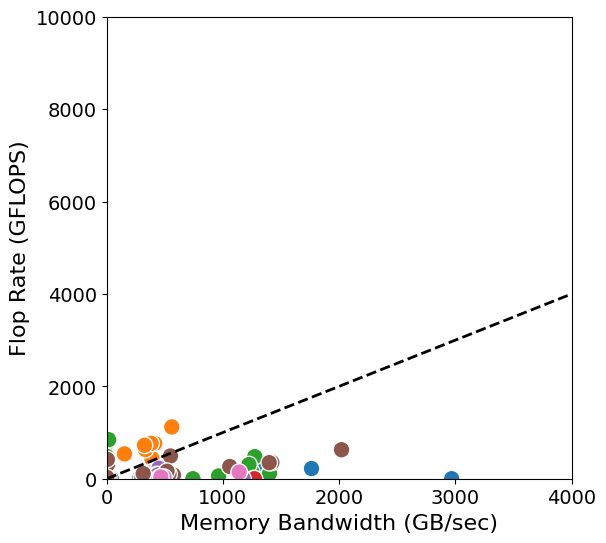

<Figure size 800x200 with 0 Axes>

In [36]:
# DDR Plot
fig_mem_v_flop_ddr, ax_mem_v_flop_ddr = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[ddr_mem_bw_mean],
    y=mem_v_flop_df[ddr_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_ddr,
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_ddr.set_xlim(left=0, right=4000)
ax_mem_v_flop_ddr.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_ddr.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_ddr.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_ddr.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_ddr.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_ddr, [0, 0], [mem_v_flop_df[ddr_mem_bw_mean].max(), mem_v_flop_df[ddr_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
sns.move_legend(ax_mem_v_flop_ddr, "center", title="Category")

mem_v_flop_figlegend = plt.figure(figsize=(8,2))
mem_v_flop_patches, mem_v_flop_labels = ax_mem_v_flop_ddr.get_legend_handles_labels()
mem_v_flop_figlegend.legend(mem_v_flop_patches, mem_v_flop_labels, title="Kernel Group", ncols=7, fontsize=18, title_fontsize=18)
ax_mem_v_flop_ddr.get_legend().remove()

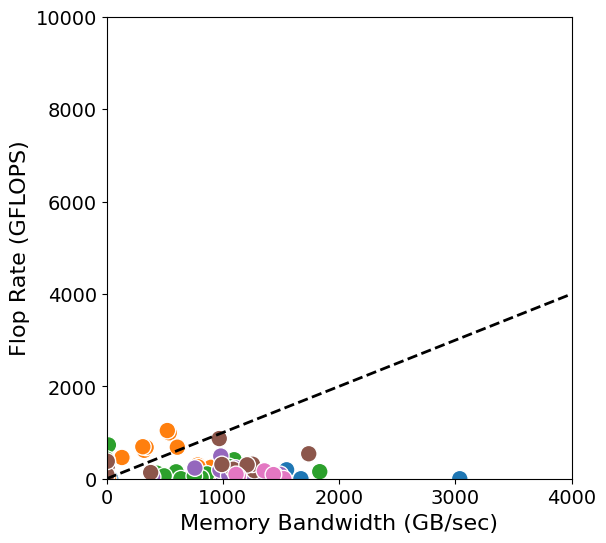

In [37]:
# HBM Plot
fig_mem_v_flop_hbm, ax_mem_v_flop_hbm = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[hbm_mem_bw_mean],
    y=mem_v_flop_df[hbm_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_hbm,
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_hbm.set_xlim(left=0, right=4000)
ax_mem_v_flop_hbm.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_hbm.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_hbm.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_hbm.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_hbm.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_hbm, [0, 0], [mem_v_flop_df[hbm_mem_bw_mean].max(), mem_v_flop_df[hbm_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
ax_mem_v_flop_hbm.get_legend().remove()

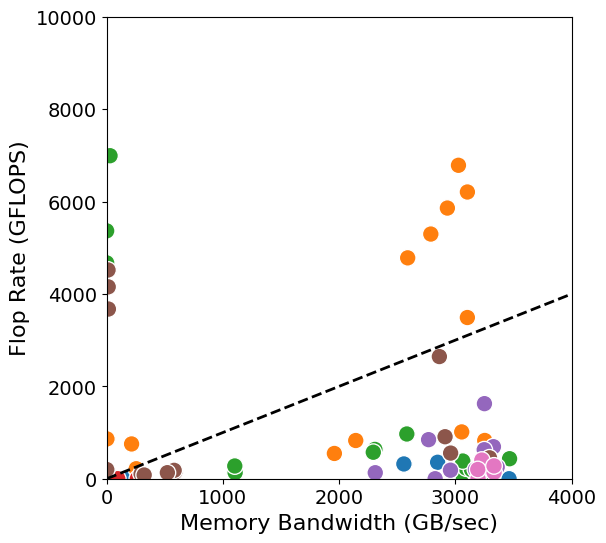

In [38]:
# V100 Plot
fig_mem_v_flop_v100, ax_mem_v_flop_v100 = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    x=mem_v_flop_df[v100_mem_bw_mean],
    y=mem_v_flop_df[v100_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    ax=ax_mem_v_flop_v100,
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_v100.set_xlim(left=0, right=4000)
ax_mem_v_flop_v100.set_ylim(bottom=0, top=10000)
ax_mem_v_flop_v100.set_xticks([0, 1000, 2000, 3000, 4000], [0, 1000, 2000, 3000, 4000])
ax_mem_v_flop_v100.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_v100.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_v100.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_v100, [0, 0], [mem_v_flop_df[v100_mem_bw_mean].max(), mem_v_flop_df[v100_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)
ax_mem_v_flop_v100.get_legend().remove()

[78.08415154702564, 232.7303250881792, 5027.180709278552, 7884.638183530316]
[13326.385238341536, 84113.33073775537, 11259.015340240285, 14974.466514869282]
['Basic_MAT_MAT_SHARED', 'Apps_EDGE3D', 'Apps_VOL3D', 'Apps_DIFFUSION3DPA']


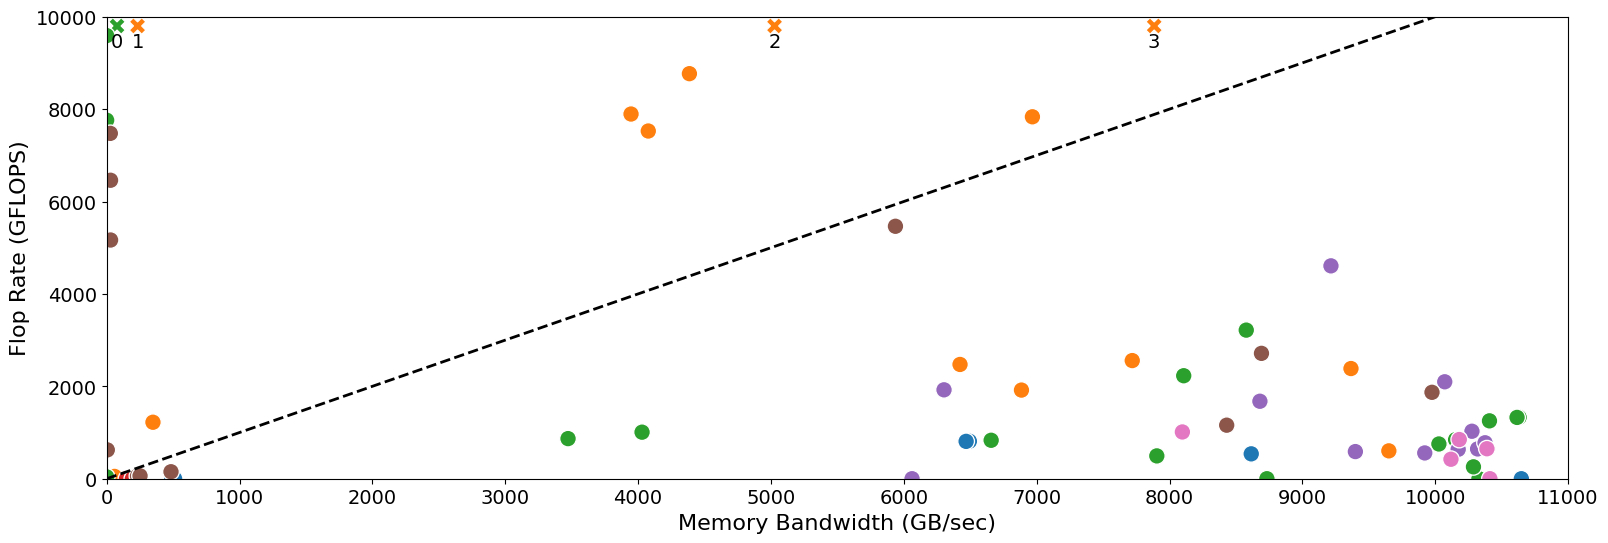

In [39]:
# MI250X Plot
fig_mem_v_flop_mi250x, ax_mem_v_flop_mi250x = plt.subplots(figsize=(6*(11000 / 3500), 6))

mi250x_ylim = 10000
mi250x_ylim_pad = 200

new_mi250x_x = mem_v_flop_df[mi250x_mem_bw_mean].tolist()
new_mi250x_y = mem_v_flop_df[mi250x_flop_rate_mean].tolist()
label_mi250x_markers = [0 for _ in range(len(new_mi250x_x))]
labels_mi250x = []
for i in range(len(new_mi250x_x)):
    y = new_mi250x_y[i]
    if y > mi250x_ylim:
        labels_mi250x.append((new_mi250x_x[i], new_mi250x_y[i], i))
        new_mi250x_y[i] = mi250x_ylim - mi250x_ylim_pad
        label_mi250x_markers[i] = 1
        
labels_mi250x = list(sorted(labels_mi250x, key=lambda tup: tup[0]))
label_mi250x_x = [tup[0] for tup in labels_mi250x]
label_mi250x_y = [tup[1] for tup in labels_mi250x]
label_mi250x_names = [tup[2] for tup in labels_mi250x]
        
label_mi250x_names = [mem_v_flop_df[("name", "")].iloc[i] for i in label_mi250x_names]
print(label_mi250x_x)
print(label_mi250x_y)
print(label_mi250x_names)

sns.scatterplot(
    x=np.array(new_mi250x_x),  # mem_v_flop_df[mi250x_mem_bw_mean],
    y=np.array(new_mi250x_y),  # mem_v_flop_df[mi250x_flop_rate_mean],
    hue=mem_v_flop_df[("groups", "")],
    style=label_mi250x_markers,
    ax=ax_mem_v_flop_mi250x,
    s=4 * mpl.rcParams['lines.markersize'] ** 2,
)
ax_mem_v_flop_mi250x.set_xlim(left=0, right=11000)
ax_mem_v_flop_mi250x.set_ylim(bottom=0, top=mi250x_ylim) # 90000
ax_mem_v_flop_mi250x.set_xticks(list(range(0, 11001, 1000)), list(range(0, 11001, 1000)))
ax_mem_v_flop_mi250x.set_xlabel("Memory Bandwidth (GB/sec)", fontsize=16)
ax_mem_v_flop_mi250x.set_ylabel("Flop Rate (GFLOPS)", fontsize=16)
ax_mem_v_flop_mi250x.tick_params(axis="both", which="major", labelsize=14)
plot_straight_line(ax_mem_v_flop_mi250x, [0, 0], [mem_v_flop_df[mi250x_mem_bw_mean].max(), mem_v_flop_df[mi250x_mem_bw_mean].max()], c="k", linestyle="--", linewidth=2)

for i in range(len(label_mi250x_x)):
    label_pt = (label_mi250x_x[i], mi250x_ylim - 2.75*mi250x_ylim_pad)
    ax_mem_v_flop_mi250x.annotate(
        "{}".format(i),
        xy=label_pt,
        xytext=(0,0),
        fontsize=14,
        textcoords='offset points',
        ha="center",
        va="center",
    )

ax_mem_v_flop_mi250x.get_legend().remove()

## Plot Bytes Read/Rep, Bytes Written per Rep, FLOPs per Rep, and FLOPs per Byte

In [40]:
analytic_metric_color_map = sns.color_palette("colorblind")

In [41]:
analytic_met_read_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_read_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_write_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_write_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
]]
analytic_met_read_df.columns = analytic_met_read_df.columns.to_flat_index()
analytic_met_read_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_read_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["FLOPs/Byte"] = analytic_met_read_df["FLOPs/Byte"].apply(lambda x: x if x < 1000 else 0.0)
analytic_met_write_df.columns = analytic_met_write_df.columns.to_flat_index()
analytic_met_write_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_write_per_rep_scaled_mean: "BytesR/W",
        ddr_flops_per_rep_scaled_mean: "FLOPs",
        ddr_flops_per_byte_mean: "FLOPs/Byte",
    },
    inplace=True
)
analytic_met_read_df["type"] = "Read"
analytic_met_write_df["type"] = "Write"
analytic_met_df = pd.concat([analytic_met_read_df, analytic_met_write_df]).reset_index(drop=True)

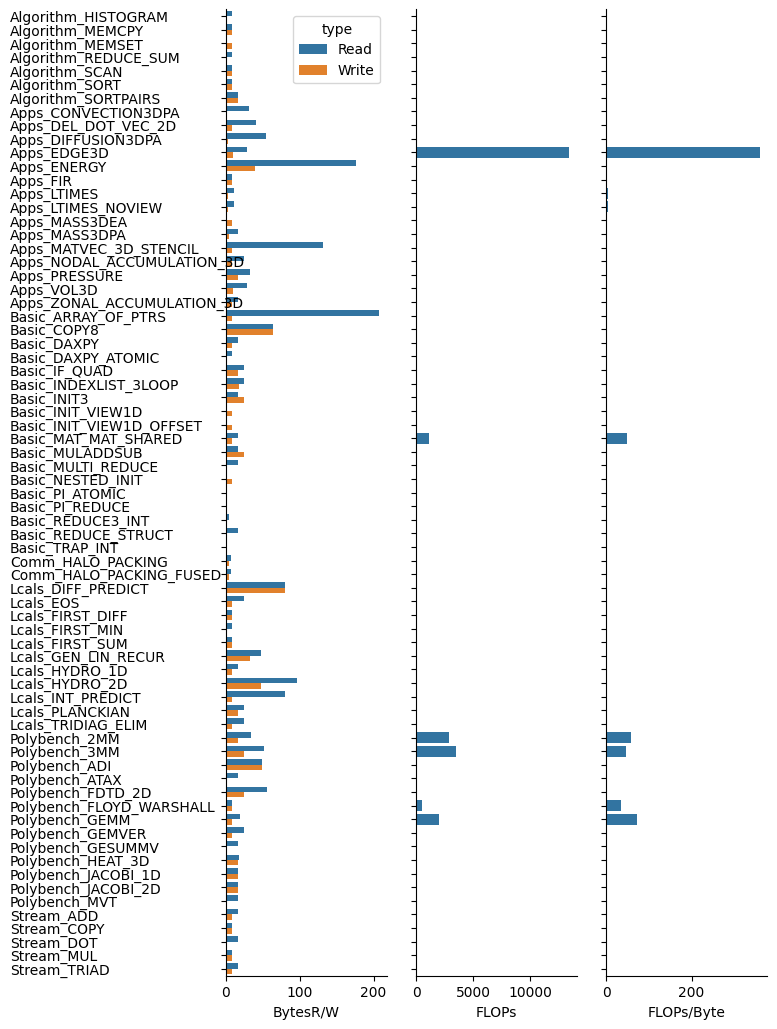

In [42]:
pg_analytic = sns.PairGrid(
    data=analytic_met_read_df,
    y_vars=["Kernel"],
    x_vars=["BytesR/W", "FLOPs", "FLOPs/Byte"],
    despine=True,
    height=10.5,
    aspect=0.2
)
pg_analytic.tight_layout()
pg_analytic.map(sns.barplot)

pg_analytic.figure.axes[0].clear()
sns.barplot(
    data=analytic_met_df,
    y="Kernel",
    x="BytesR/W",
    hue="type",
    ax=pg_analytic.figure.axes[0],
)
pg_analytic.figure.axes[0].get_yaxis().get_label().set_visible(False)

pg_analytic_y_ax = pg_analytic.figure.axes[0].get_yaxis()
pg_analytic_y_ax.set_tick_params(pad=152)
for tick in pg_analytic_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

# Plot DDR Top-Down

In [43]:
ddr_tma_df = th.statsframe.dataframe[[
    ("name", ""),
    # ddr_mem_bw_mean,
    # ddr_flop_rate_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean
]]
ddr_tma_df.columns = ddr_tma_df.columns.to_flat_index()
ddr_tma_df.rename(
    columns={
        ("name", ""): "Kernel",
        # ddr_mem_bw_mean: "Memory Bandwidth (GiB/s)",
        # ddr_flop_rate_mean: "FLOP Rate (GiFLOPS/s)",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

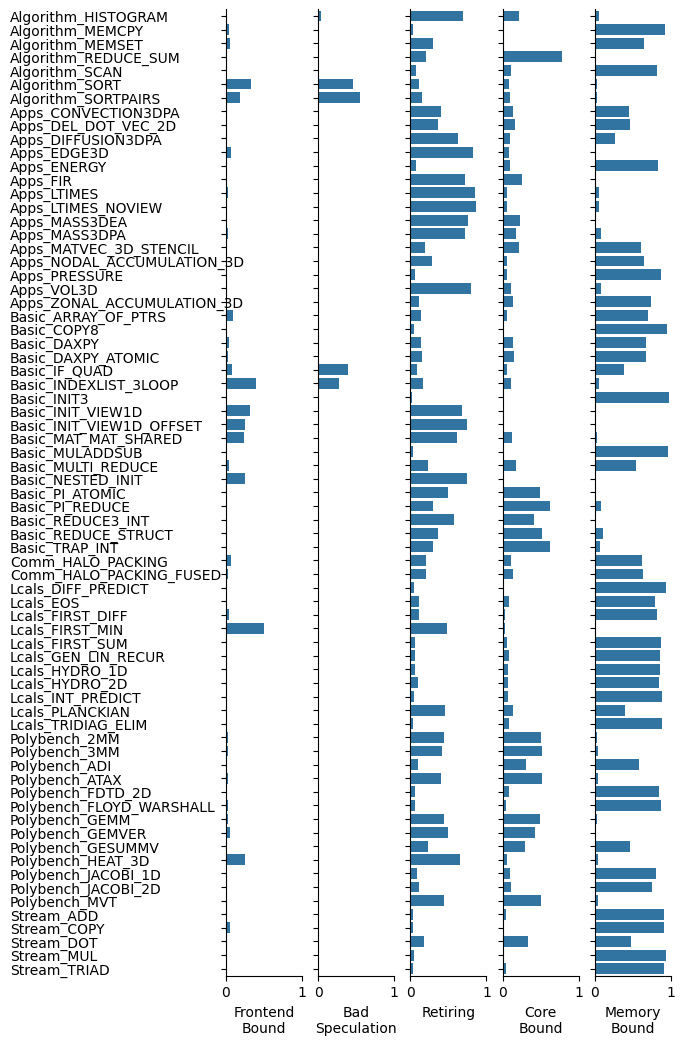

In [44]:
pg_ddr_tma = sns.PairGrid(
    data=ddr_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        # "Memory Bandwidth (GiB/s)",
        # "FLOP Rate (GiFLOPS/s)",
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1
)
pg_ddr_tma.tight_layout()
pg_ddr_tma.map(sns.barplot)
pg_ddr_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_ddr_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_ddr_tma_y_ax = pg_ddr_tma.figure.axes[0].get_yaxis()
pg_ddr_tma_y_ax.set_tick_params(pad=152)
for tick in pg_ddr_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_ddr_tma.figure.savefig("figures/ddr_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

# Plot HBM Top-Down

In [45]:
hbm_tma_df = th.statsframe.dataframe[[
    ("name", ""),
    # hbm_mem_bw_mean,
    # hbm_flop_rate_mean,
    hbm_fe_bound_mean,
    hbm_bad_spec_mean,
    hbm_retiring_mean,
    hbm_core_bound_mean,
    hbm_mem_bound_mean
]]
hbm_tma_df.columns = hbm_tma_df.columns.to_flat_index()
hbm_tma_df.rename(
    columns={
        ("name", ""): "Kernel",
        # hbm_mem_bw_mean: "Memory Bandwidth (GiB/s)",
        # hbm_flop_rate_mean: "FLOP Rate (GiFLOPS/s)",
        hbm_fe_bound_mean: "Frontend Bound",
        hbm_bad_spec_mean: "Bad Speculation",
        hbm_retiring_mean: "Retiring",
        hbm_core_bound_mean: "Core Bound",
        hbm_mem_bound_mean: "Memory Bound",
    },
    inplace=True
)

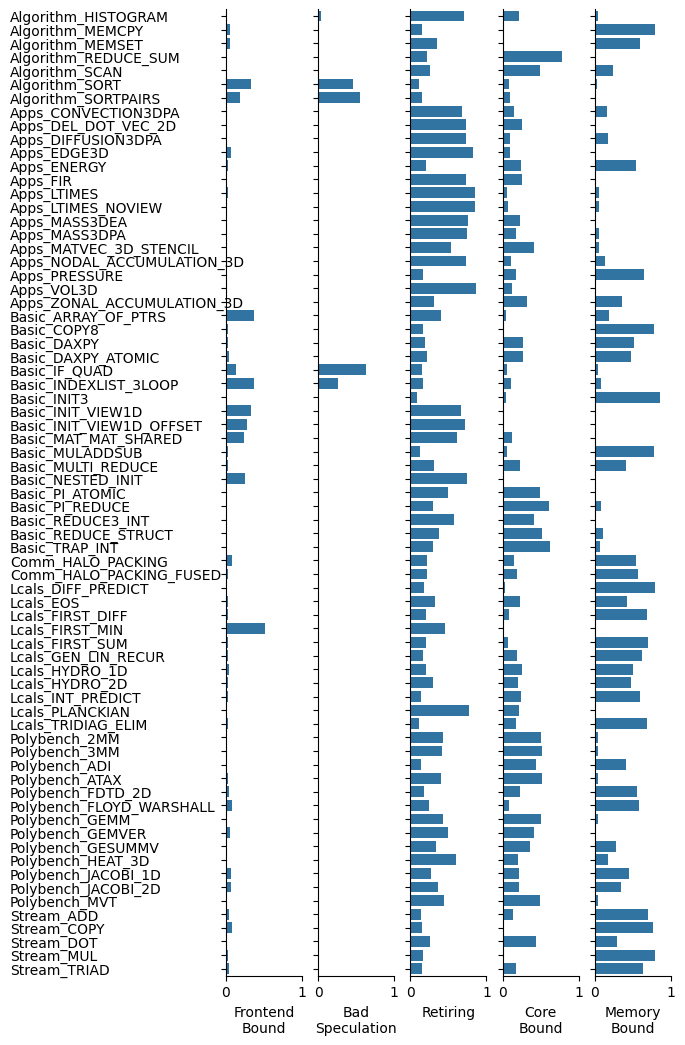

In [46]:
pg_hbm_tma = sns.PairGrid(
    data=hbm_tma_df,
    y_vars=["Kernel"],
    x_vars=[
        # "Memory Bandwidth (GiB/s)",
        # "FLOP Rate (GiFLOPS/s)",
        "Frontend Bound",
        "Bad Speculation",
        "Retiring",
        "Core Bound",
        "Memory Bound"
    ],
    despine=True,
    height=10.5,
    aspect=0.1
)
pg_hbm_tma.tight_layout()
pg_hbm_tma.map(sns.barplot)
pg_hbm_tma.figure.axes[0].get_yaxis().get_label().set_visible(False)
for ax in pg_hbm_tma.figure.axes:
    ax.set_xlim(0, 1)
    ax.set_xlabel(ax.get_xlabel().replace(" ", "\n"))
pg_hbm_tma_y_ax = pg_hbm_tma.figure.axes[0].get_yaxis()
pg_hbm_tma_y_ax.set_tick_params(pad=152)
for tick in pg_hbm_tma_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")
#pg_hbm_tma.figure.savefig("figures/hbm_topdown_per_kernel.png", bbox_inches="tight", dpi=200)

## Plot Speedup, DDR Memory Bound, and HBM Memory Bound

In [47]:
triple_plot_df = th.statsframe.dataframe[[("name", ""), ddr_mem_bound_mean, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_mi250x_speedup]].reset_index(drop=True)
triple_plot_df.reset_index(inplace=True)
triple_plot_df

,index,name,ddr_topdown,hbm,v100,mi250x
,,,Memory bound_mean,speedup,speedup,speedup
0,0,Algorithm_HISTOGRAM,0.049784,0.878386,1.448340,3.684487
1,1,Algorithm_MEMCPY,0.922720,3.386796,6.473918,21.017597
2,2,Algorithm_MEMSET,0.646944,1.023321,1.166566,3.588471
3,3,Algorithm_REDUCE_SUM,0.007449,0.863619,2.139605,4.882868
4,4,Algorithm_SCAN,0.811522,2.927147,6.201060,17.215451
...,...,...,...,...,...,...
66,66,Stream_ADD,0.915294,2.362050,6.953190,21.112355
67,67,Stream_COPY,0.909846,3.074465,6.459098,21.052661
68,68,Stream_DOT,0.473905,1.188229,2.831148,7.101520


In [48]:
triple_plot_df.columns = triple_plot_df.columns.to_flat_index()
triple_plot_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_mem_bound_mean: "DDR Memory Bound",
        ddr_to_hbm_speedup: "SPR-HBM Speedup",
        ddr_to_v100_speedup: "V100 Speedup",
        ddr_to_mi250x_speedup: "MI250X Speedup",
    },
    inplace=True
)

In [49]:
ddr_stream_copy_mem_bound = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["DDR Memory Bound"].iloc[0]
hbm_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["SPR-HBM Speedup"].iloc[0]
v100_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["V100 Speedup"].iloc[0]
mi250x_stream_copy_spdup = triple_plot_df[triple_plot_df["Kernel"] == "Stream_TRIAD"]["MI250X Speedup"].iloc[0]

In [50]:
#sns.set_palette("colorblind")
sns.set_theme(palette="tab10", font_scale=0.8)
sns.set_style("ticks")

In [51]:
triple_plot_df["color"] = 1

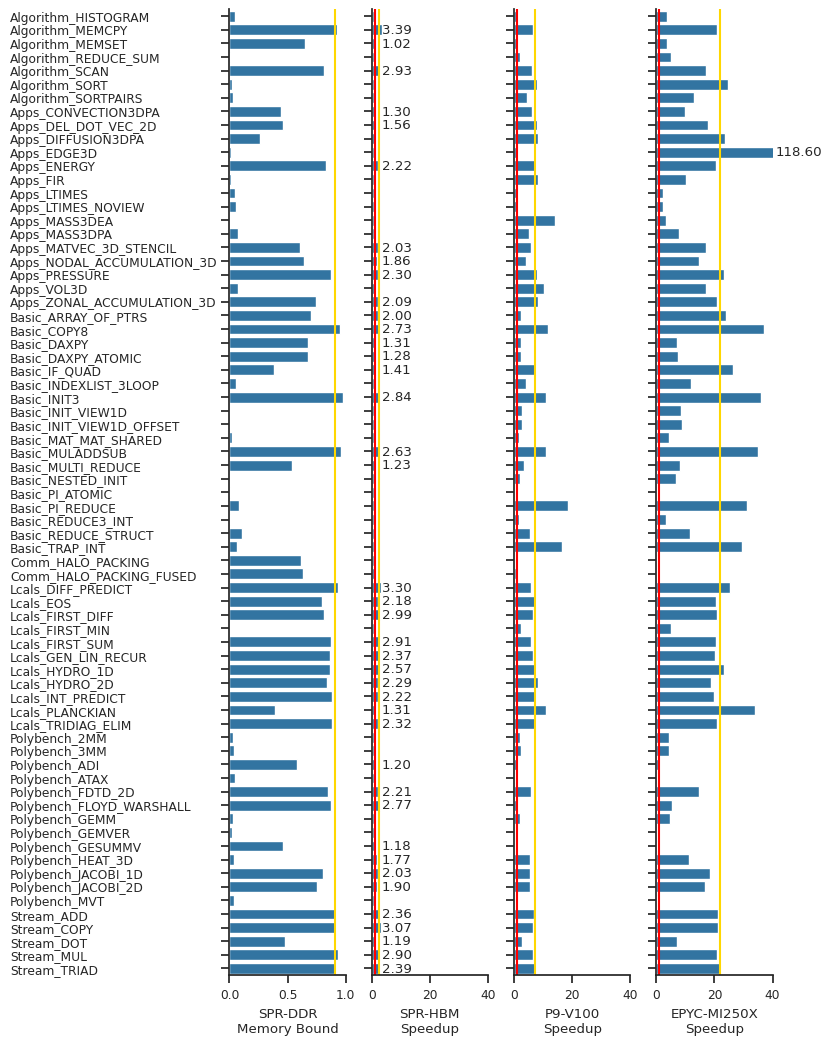

In [52]:
pg_triple = sns.PairGrid(
    data=triple_plot_df,
    y_vars=["Kernel"],
    x_vars=["DDR Memory Bound", "SPR-HBM Speedup", "V100 Speedup", "MI250X Speedup"],
    despine=True,
    height=10.5,
    aspect=0.15,
    hue="color"
)
pg_triple.tight_layout()
pg_triple.map(sns.barplot)
pg_triple.figure.axes[0].set_xlim(0, 1)
pg_triple.figure.axes[0].set_xlabel("SPR-DDR\nMemory Bound")
pg_triple.figure.axes[0].get_yaxis().get_label().set_visible(False)
pg_triple.figure.axes[0].axvline(ddr_stream_copy_mem_bound, color="gold")
pg_triple.figure.axes[1].axvline(1.0, color="red")
pg_triple.figure.axes[1].axvline(hbm_stream_copy_spdup, color="gold")
pg_triple.figure.axes[1].set_xlim(0, 40)
pg_triple.figure.axes[1].set_xlabel("SPR-HBM\nSpeedup")
pg_triple.figure.axes[2].axvline(1.0, color="red")
pg_triple.figure.axes[2].axvline(v100_stream_copy_spdup, color="gold")
pg_triple.figure.axes[2].set_xlim(0, 40)
pg_triple.figure.axes[2].set_xlabel("P9-V100\nSpeedup")
pg_triple.figure.axes[3].axvline(1.0, color="red")
pg_triple.figure.axes[3].axvline(mi250x_stream_copy_spdup, color="gold")
pg_triple.figure.axes[3].set_xlim(0, 40)
pg_triple.figure.axes[3].set_xlabel("EPYC-MI250X\nSpeedup")

gpu_stream_copy_spdups = {
    "V100": v100_stream_copy_spdup,
    "MI250X": mi250x_stream_copy_spdup,
}

starting_subplot_idx = 2
            
for i, gpu_type in enumerate(["V100", "MI250X"]):
    for label in pg_triple.figure.axes[0].get_yticklabels():
        _, label_y = label.get_position()
        min_x, max_x = pg_triple.figure.axes[starting_subplot_idx+i].get_xlim()
        curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["{} Speedup".format(gpu_type)].iloc[0]
        if curr_kernel_speedup > max_x:
            pg_triple.figure.axes[starting_subplot_idx+i].annotate(
                "{:.2f}".format(curr_kernel_speedup),
                xy=(max_x, label_y),
                xytext=(2, 0),
                textcoords='offset points',
                ha="left",
                va="center",
            )
starting_subplot_idx = 0         
for label in pg_triple.figure.axes[0].get_yticklabels():
    _, label_y = label.get_position()
    curr_kernel_speedup = triple_plot_df[triple_plot_df["Kernel"] == label.get_text()]["SPR-HBM Speedup"].iloc[0]
    if curr_kernel_speedup > 1:
        pg_triple.figure.axes[starting_subplot_idx+i].annotate(
            "{:.2f}".format(curr_kernel_speedup),
            xy=(2, label_y),
            xytext=(3, 0),
            textcoords='offset points',
            ha="left",
            va="center",
        )

pg_triple_y_ax = pg_triple.figure.axes[0].get_yaxis()
pg_triple_y_ax.set_tick_params(pad=152)
for tick in pg_triple_y_ax.get_majorticklabels():
    tick.set_horizontalalignment("left")

## Cluster Kernels with DDR Data (Agglomerative Clustering)

Set `clustering_metrics` to the metrics/column names you want to use in clustering

In [53]:
# Try bytes/rep, flops/rep, and flops/bytes (divide by problem size first)
clustering_metrics = [
    ddr_retiring_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
]

In [54]:
clustering_data = th.statsframe.dataframe.loc[:, clustering_metrics].copy(deep=True)

# Cluster with Aglomerative Clustering

In [55]:
thresh = 1.4
cluster_op = sk.AgglomerativeClustering(linkage="ward", distance_threshold=thresh, n_clusters=None, compute_full_tree=True)
th.statsframe.dataframe[("label", "")] = cluster_op.fit_predict(clustering_data)

# Plot Dendrogram

In [56]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    return dendrogram(linkage_matrix, **kwargs)

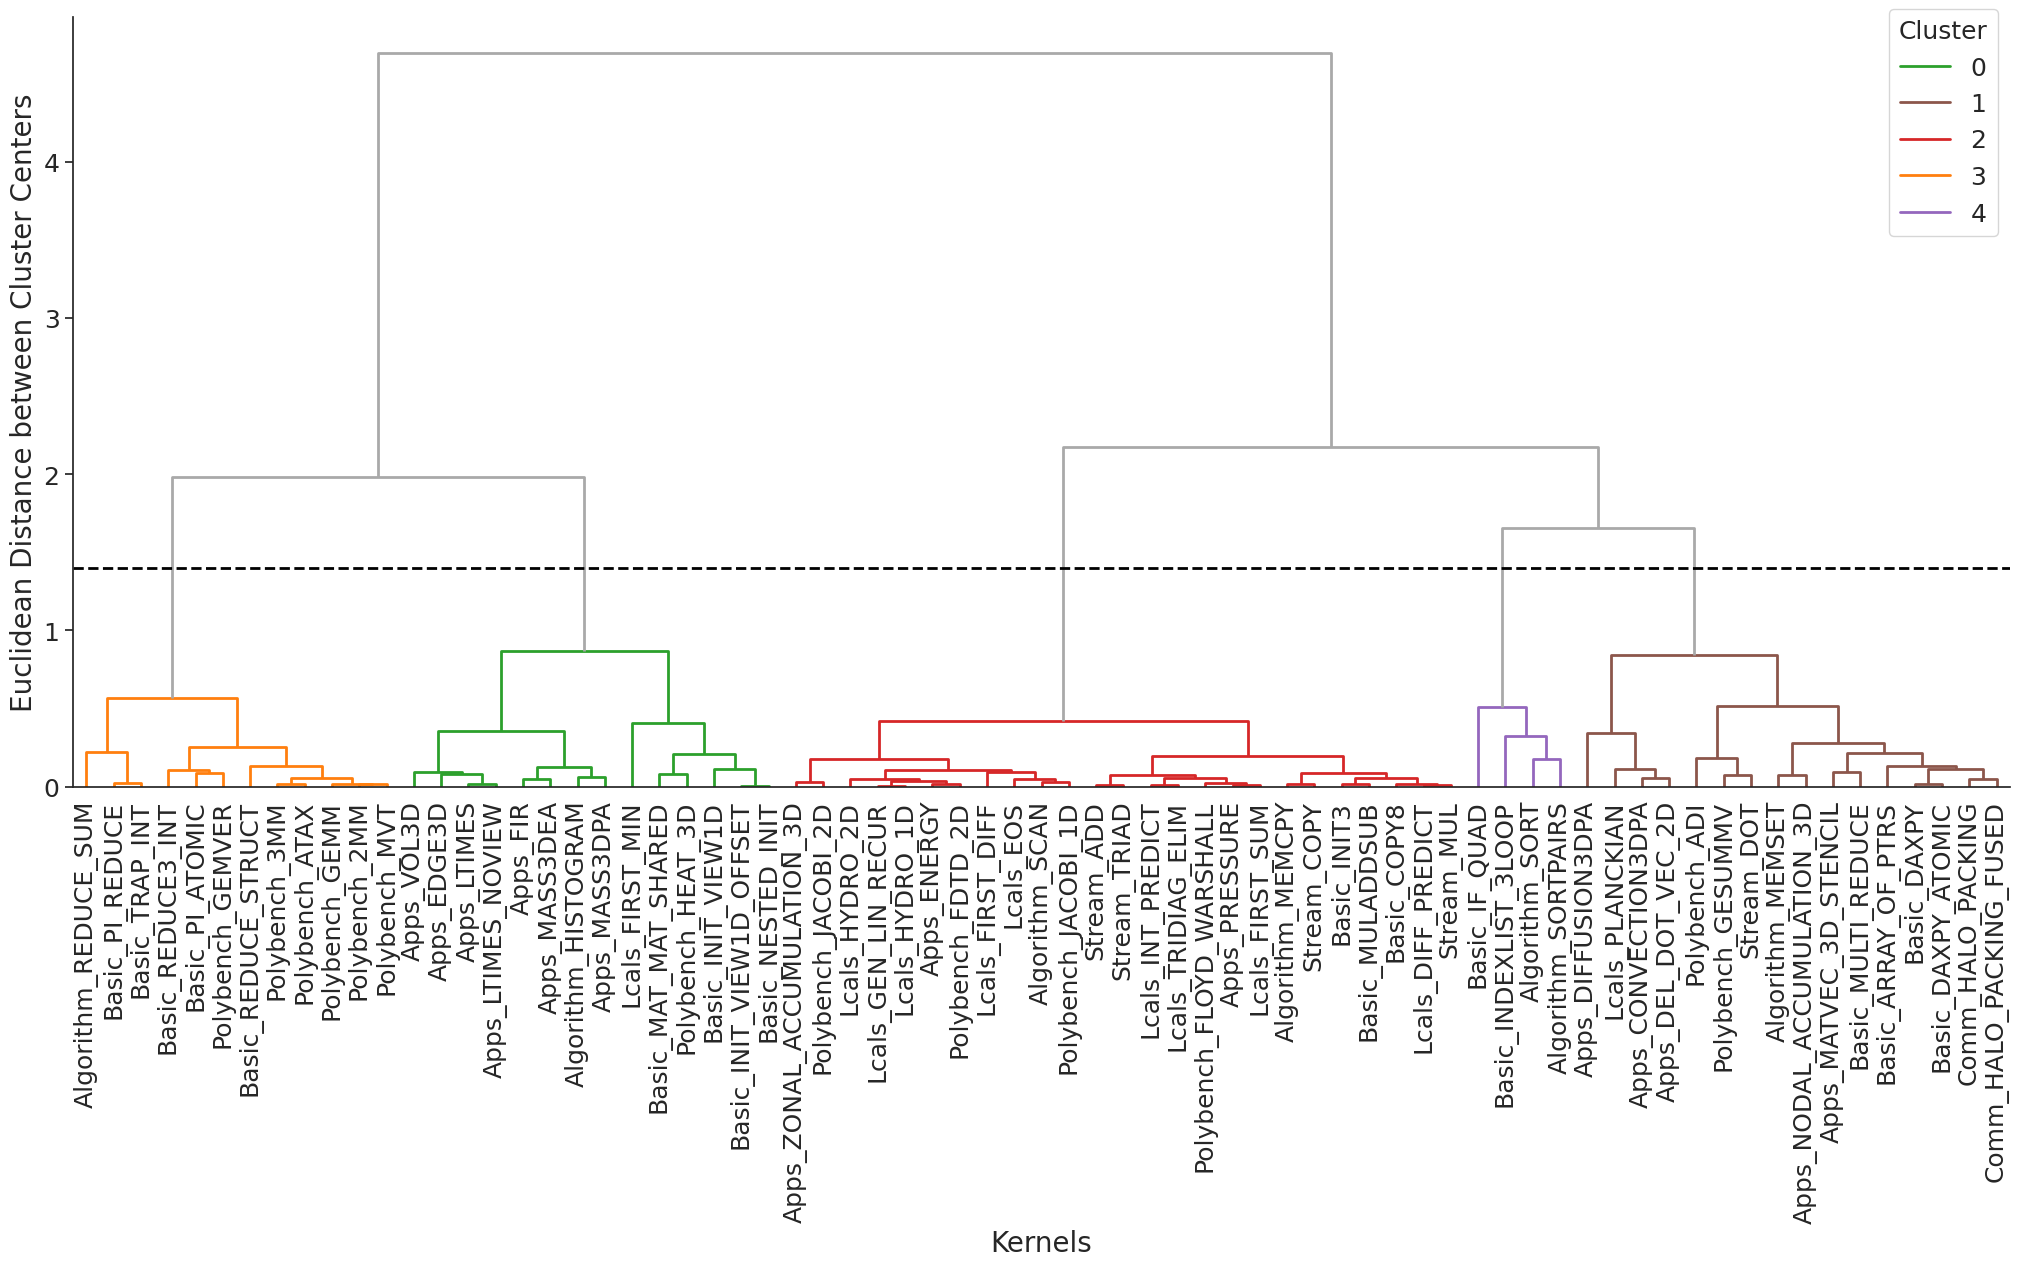

In [57]:
dendro_fig, dendro_ax = plt.subplots(figsize=(25, 10))

with plt.rc_context({'lines.linewidth': 2}):
    dendro_dict = plot_dendrogram(
        cluster_op,
        ax=dendro_ax,
        color_threshold=thresh,
        labels=th.statsframe.dataframe[("name", "")],
        above_threshold_color="darkgray",
    )

    dendro_colors = {th.statsframe.dataframe[("label", "")].iloc[l]: c for l, c in zip(dendro_dict["leaves"], dendro_dict["leaves_color_list"])}
    dendro_labels = list(sorted([l for l in dendro_colors.keys()]))
    dendro_handles = []
    for label in dendro_labels:
        dendro_handles.append(plt.Line2D([0], [0], color=dendro_colors[label]))

    dendro_fig.legend(
        dendro_handles,
        dendro_labels,
        title="Cluster",
        loc="upper right",
        bbox_to_anchor=(0.9, 0.9),
        title_fontsize=18,
        fontsize=18,
    )
    dendro_ax.axhline(thresh, color="k", linestyle="--")

dendro_ax.spines[['right', 'top']].set_visible(False)
dendro_ax.set_ylabel("Euclidean Distance between Cluster Centers", fontsize=20)
dendro_ax.set_xlabel("Kernels", fontsize=20)
dendro_ax.tick_params(axis="both", which="major", labelsize=18)

#dendro_fig.savefig("figures/clustering_dendrogram.png", bbox_inches="tight", dpi=200)

# Summarize Clusters

In [58]:
cluster_summary_df = th.statsframe.dataframe[[("name", ""), *clustering_metrics, ddr_to_hbm_speedup, ddr_to_v100_speedup, ddr_to_mi250x_speedup, ("label", "")]].reset_index(drop=True)
cluster_summary_df.columns = cluster_summary_df.columns.to_flat_index()
cluster_summary_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ("label", ""): "Cluster ID",
    },
    inplace=True
)
cluster_summary_df

,Kernel,Retiring,Frontend Bound,Bad Speculation,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X,Cluster ID
0,Algorithm_HISTOGRAM,0.690707,0.010253,0.035223,0.214034,0.049784,0.878386,1.448340,3.684487,0
1,Algorithm_MEMCPY,0.034130,0.036830,0.000045,0.006275,0.922720,3.386796,6.473918,21.017597,2
2,Algorithm_MEMSET,0.299764,0.052811,0.000090,0.000392,0.646944,1.023321,1.166566,3.588471,1
3,Algorithm_REDUCE_SUM,0.208152,0.003664,0.000258,0.780477,0.007449,0.863619,2.139605,4.882868,3
4,Algorithm_SCAN,0.067790,0.007750,0.000087,0.112851,0.811522,2.927147,6.201060,17.215451,2
...,...,...,...,...,...,...,...,...,...,...
66,Stream_ADD,0.035294,0.004228,0.000086,0.045098,0.915294,2.362050,6.953190,21.112355,2
67,Stream_COPY,0.036062,0.047398,0.000034,0.006661,0.909846,3.074465,6.459098,21.052661,2
68,Stream_DOT,0.181774,0.007289,0.000165,0.336867,0.473905,1.188229,2.831148,7.101520,1
69,Stream_MUL,0.043580,0.009357,0.000064,0.012957,0.934042,2.902520,6.459979,21.022930,2


In [59]:
tma_metric_dfs = []
for m in ["Retiring", "Frontend Bound", "Bad Speculation", "Core Bound", "Memory Bound"]:
    single_tma_metric_df = cluster_summary_df[["Kernel", m, "Cluster ID"]]
    single_tma_metric_df.rename(columns={m: "TMA Metric"}, inplace=True)
    single_tma_metric_df["type"] = m
    tma_metric_dfs.append(single_tma_metric_df)

clustering_plotting_metric_df = pd.concat(tma_metric_dfs)

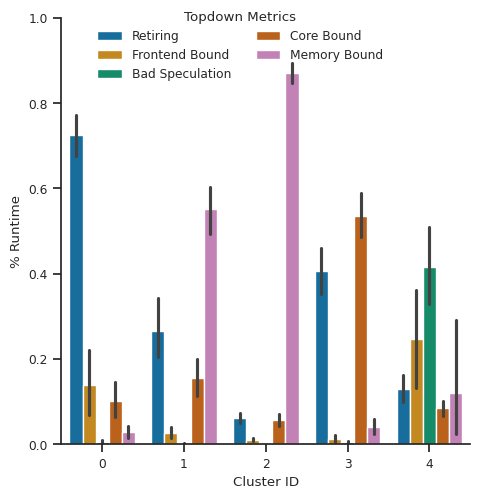

In [60]:
fg_cluster_summary = sns.catplot(
    data=clustering_plotting_metric_df,
    x="Cluster ID",
    y="TMA Metric",
    hue="type",
    kind="bar",
    palette="colorblind",
)
fg_cluster_summary.ax.set_ylabel("% Runtime")
# fg_cluster_summary.legend.set_title("Topdown Metrics")
# fg_cluster_summary.legend.set_ncols(5)
fg_cluster_summary.ax.set_ylim(bottom=0, top=1)
sns.move_legend(fg_cluster_summary, "upper center", title="Topdown Metrics", ncols=2)

# Parallel Coordinate Plots

In [61]:
import os

import plotly.graph_objects as go

if not os.path.exists("images"):
    os.mkdir("images")

In [62]:
kernels = [
    "Algorithm_HISTOGRAM",
    "Polybench_FLOYD_WARSHALL",
    "Polybench_GEMM"
]

In [63]:
# Grab just the relevant metrics from above
# TODO: make sure only O(n) here
relevant_metrics_df = th.statsframe.dataframe[[
    ("name", ""),
    ddr_bytes_read_per_rep_scaled_mean,
    ddr_bytes_write_per_rep_scaled_mean,
    ddr_flops_per_rep_scaled_mean,
    ddr_flops_per_byte_mean,
    ddr_no_topdown_time_metric_mean,
    hbm_no_topdown_time_metric_mean,
    v100_time_metric_mean,
    mi250x_time_metric_mean,
    ddr_mem_bw_mean,
    ddr_flop_rate_mean,
    hbm_mem_bw_mean,
    hbm_flop_rate_mean,
    v100_mem_bw_mean,
    v100_flop_rate_mean,
    mi250x_mem_bw_mean,
    mi250x_flop_rate_mean,
    ddr_fe_bound_mean,
    ddr_bad_spec_mean,
    ddr_retiring_mean,
    ddr_core_bound_mean,
    ddr_mem_bound_mean,
    ddr_to_hbm_speedup,
    ddr_to_v100_speedup,
    ddr_to_mi250x_speedup,
    ("label", ""),
]].copy(deep=True)
relevant_metrics_df.columns = relevant_metrics_df.columns.to_flat_index()
relevant_metrics_df.rename(
    columns={
        ("name", ""): "Kernel",
        ddr_bytes_read_per_rep_scaled_mean: "BytesRead",
        ddr_bytes_write_per_rep_scaled_mean: "BytesWrite",
        ddr_flops_per_rep_scaled_mean: "FLOP",
        ddr_flops_per_byte_mean: "FLOP/Byte",
        ddr_no_topdown_time_metric_mean: "SPR-DDR Time",
        hbm_no_topdown_time_metric_mean: "SPR-HBM Time",
        v100_time_metric_mean: "P9-V100 Time",
        mi250x_time_metric_mean: "EPYC-MI250X Time",
        ddr_mem_bw_mean: "SPR-DDR Memory Bandwidth (GB/sec)",
        ddr_flop_rate_mean: "SPR-DDR Flop Rate (GFLOPS)",
        hbm_mem_bw_mean: "SPR-HBM Memory Bandwidth (GB/sec)",
        hbm_flop_rate_mean: "SPR-HBM Flop Rate (GFLOPS)",
        v100_mem_bw_mean: "P9-V100 Memory Bandwidth (GB/sec)",
        v100_flop_rate_mean: "P9-V100 Flop Rate (GFLOPS)",
        mi250x_mem_bw_mean: "EPYC-MI250X Memory Bandwidth (GB/sec)",
        mi250x_flop_rate_mean: "EPYC-MI250X Flop Rate (GFLOPS)",
        ddr_fe_bound_mean: "Frontend Bound",
        ddr_bad_spec_mean: "Bad Speculation",
        ddr_retiring_mean: "Retiring",
        ddr_core_bound_mean: "Core Bound",
        ddr_mem_bound_mean: "Memory Bound",
        ddr_to_hbm_speedup: "Speedup on SPR-HBM",
        ddr_to_v100_speedup: "Speedup on P9-V100",
        ddr_to_mi250x_speedup: "Speedup on EPYC-MI250X",
        ("label", ""): "Cluster ID",
    },
    inplace=True,
)
relevant_metrics_df.reset_index(inplace=True, drop=True)
relevant_metrics_df.sort_values(by="Kernel", inplace=True)
relevant_metrics_df

,Kernel,BytesRead,BytesWrite,FLOP,FLOP/Byte,SPR-DDR Time,SPR-HBM Time,P9-V100 Time,EPYC-MI250X Time,SPR-DDR Memory Bandwidth (GB/sec),...,EPYC-MI250X Flop Rate (GFLOPS),Frontend Bound,Bad Speculation,Retiring,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X,Cluster ID
0,Algorithm_HISTOGRAM,8.000267,0.000267,1.0,0.124992,0.038085,0.043358,0.026296,0.010337,1762.295247,...,8.116977e+02,0.010253,0.035223,0.690707,0.214034,0.049784,0.878386,1.448340,3.684487,0
1,Algorithm_MEMCPY,8.000000,8.000000,0.0,0.000000,0.545455,0.161054,0.084254,0.025952,492.139527,...,3.429483e-312,0.036830,0.000045,0.034130,0.006275,0.922720,3.386796,6.473918,21.017597,2
2,Algorithm_MEMSET,0.000000,8.000000,0.0,0.000000,0.045232,0.044201,0.038773,0.012605,2967.769980,...,7.061081e-312,0.052811,0.000090,0.299764,0.000392,0.646944,1.023321,1.166566,3.588471,1
3,Algorithm_REDUCE_SUM,8.000027,0.000027,1.0,0.124999,0.050691,0.058696,0.023692,0.010381,1323.882004,...,8.086469e+02,0.003664,0.000258,0.208152,0.780477,0.007449,0.863619,2.139605,4.882868,3
4,Algorithm_SCAN,8.000000,8.000000,1.0,0.062500,0.536408,0.183253,0.086503,0.031159,500.440876,...,5.384469e+02,0.007750,0.000087,0.067790,0.112851,0.811522,2.927147,6.201060,17.215451,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Stream_ADD,16.000000,8.000000,1.0,0.041667,8.401478,3.556858,1.208291,0.397941,479.267233,...,4.215999e+02,0.004228,0.000086,0.035294,0.045098,0.915294,2.362050,6.953190,21.112355,2
67,Stream_COPY,8.000000,8.000000,0.0,0.000000,9.770020,3.177795,1.512598,0.464075,494.566430,...,3.452135e-312,0.047398,0.000034,0.036062,0.006661,0.909846,3.074465,6.459098,21.052661,2
68,Stream_DOT,16.000027,0.000027,2.0,0.125000,4.709796,3.963712,1.663564,0.663210,1140.064224,...,1.012097e+03,0.007289,0.000165,0.181774,0.336867,0.473905,1.188229,2.831148,7.101520,1
69,Stream_MUL,8.000000,8.000000,1.0,0.062500,9.777439,3.368603,1.513540,0.465085,494.190950,...,6.493222e+02,0.009357,0.000064,0.043580,0.012957,0.934042,2.902520,6.459979,21.022930,2


In [64]:
from scipy import stats
# Determine outliers based on speedup
z = np.abs(stats.zscore(relevant_metrics_df['Speedup on EPYC-MI250X']))
outlier_indices = np.where(z > 3)[0]
pd_no_outliers_amd = relevant_metrics_df.drop(outlier_indices)

z = np.abs(stats.zscore(relevant_metrics_df['Speedup on P9-V100']))
outlier_indices = np.where(z > 3)[0]
pd_no_outliers_v100 = relevant_metrics_df.drop(outlier_indices)

dif1 = np.setdiff1d(pd_no_outliers_amd["Kernel"], pd_no_outliers_v100["Kernel"])
dif2 = np.setdiff1d(pd_no_outliers_v100["Kernel"], pd_no_outliers_amd["Kernel"])

temp3 = np.concatenate((dif1, dif2))

In [65]:
# Remove the outliers
all_kernels_no_outliers = relevant_metrics_df[~relevant_metrics_df['Kernel'].isin(["Apps_EDGE3D", "Basic_PI_REDUCE"])]

Plot cluster values

In [66]:
fig = go.Figure(data=
    [
    go.Parcoords(
        line = dict(color = all_kernels_no_outliers['Cluster ID'], #showscale = True,
                   colorscale = [[0,'green'],[0.25, 'brown'],[0.5,'red'],[0.75, 'orange'],[1,'purple'],]),
        dimensions = list([
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Bad Speculation', values = all_kernels_no_outliers['Bad Speculation']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Frontend Bound', values = all_kernels_no_outliers['Frontend Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Core Bound', values = all_kernels_no_outliers['Core Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Memory Bound', values = all_kernels_no_outliers['Memory Bound']),
            dict(range = [0,5],
                 tickvals = [0,0.2,0.4,0.6,0.8,1],
                label = 'Retiring', values = all_kernels_no_outliers['Retiring']),
            dict(range = [-10,40],
                 tickvals = [0,5],
                label = 'SPR-HBM Speedup', values = all_kernels_no_outliers['Speedup on SPR-HBM']),
            dict(range = [-10,40],
                 tickvals = [0,5,10,15,20,],
                label = 'P9-V100 Speedup', values = all_kernels_no_outliers['Speedup on P9-V100']),
            dict(range = [-10,40],
                 tickvals = [0,10,20,30,40],
                label = 'EPYC-MI250X Speedup', values = all_kernels_no_outliers['Speedup on EPYC-MI250X'])
        ])
    #)
    ),
                    #Custom Legend
    go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="0",
            marker=dict(size=7, color="green", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="1",
            marker=dict(size=7, color="brown", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="2",
            marker=dict(size=7, color="red",),
        ),
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="3",
            marker=dict(size=7, color="orange",),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="4",
            marker=dict(size=7, color="purple",),
        ),
                        
    ]   
)

fig.update_layout(
    width=900, height=1000,
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)

fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_layout(legend=dict(
    title="Cluster",
    orientation="h",
    yanchor="auto",
    y=0.9,
    xanchor="right",  # changed
    x=0.4
    ))

#fig.write_image("images/par_coord_NO_OUTLIERS.png")

fig.show()

In [67]:
# Get the averages
avg_no_outliers = all_kernels_no_outliers.set_index("Kernel").groupby('Cluster ID', as_index=False).mean()
avg_no_outliers.head()

,Cluster ID,BytesRead,BytesWrite,FLOP,FLOP/Byte,SPR-DDR Time,SPR-HBM Time,P9-V100 Time,EPYC-MI250X Time,SPR-DDR Memory Bandwidth (GB/sec),...,EPYC-MI250X Memory Bandwidth (GB/sec),EPYC-MI250X Flop Rate (GFLOPS),Frontend Bound,Bad Speculation,Retiring,Core Bound,Memory Bound,Speedup on SPR-HBM,Speedup on P9-V100,Speedup on EPYC-MI250X
0,0,9.566122,6.430338,113.281011,4.971394,1.304560,1.271922,0.421972,0.185775,679.027153,...,4808.624081,4299.231678,0.145991,0.005019,0.716902,0.102064,0.030025,0.955922,4.550998,7.054327
1,1,40.461683,7.825444,22.433937,0.429076,1.638986,1.112435,0.611130,0.386071,848.817009,...,5876.555771,2523.399546,0.026308,0.001878,0.264454,0.156279,0.551082,1.333702,3.770129,11.034481
2,2,34.565570,19.823544,29.984549,1.493761,10.013115,4.086461,2.112694,0.606324,426.623102,...,9159.978841,1155.613963,0.010768,0.000389,0.061183,0.057326,0.870340,2.555926,7.077275,21.648792
3,3,17.150763,5.101569,767.909258,inf,0.971695,1.085324,0.948245,0.524847,724.769532,...,1656.836500,2877.939986,0.014690,0.004965,0.417680,0.526664,0.036010,0.874366,3.021282,5.807253
4,4,18.000020,14.500015,2.750000,0.068750,2.575489,2.533587,0.432616,0.137268,277.167616,...,4460.498004,557.349254,0.246461,0.416251,0.130633,0.085543,0.121112,1.001964,5.938249,18.955464


Plot average of cluster values

In [68]:
fig = go.Figure(data=
    [
    go.Parcoords(
        line = dict(color = avg_no_outliers['Cluster ID'], #showscale = True,
                   colorscale = [[0,'green'],[0.25, 'brown'],[0.5,'red'],[0.75, 'orange'],[1,'purple'],]),
        dimensions = list([
            dict(range = [0,3],
                 tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                label = 'Bad Speculation', values = avg_no_outliers['Bad Speculation']),
            dict(range = [0,3],
                 tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                label = 'Frontend Bound', values = avg_no_outliers['Frontend Bound']),
            dict(range = [0,3],
                 tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                label = 'Core Bound', values = avg_no_outliers['Core Bound']),
            dict(range = [0,3],
                 tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                label = 'Memory Bound', values = avg_no_outliers['Memory Bound']),
            dict(range = [0,3],
                 tickvals = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                label = 'Retiring', values = avg_no_outliers['Retiring']),
            dict(range = [-10,22],
                 tickvals = [0,2,4,],
                label = 'SPR-HBM Speedup', values = avg_no_outliers['Speedup on SPR-HBM']),
            dict(range = [-10,22],
                 tickvals = [0,2,4,6,8,10],
                label = 'P9-V100 Speedup', values = avg_no_outliers['Speedup on P9-V100']),
            dict(range = [-10,22],
                 tickvals = [0,2,4,6,8,10,12,14,16,18,20,22],
                label = 'EPYC-MI250X Speedup', values = avg_no_outliers['Speedup on EPYC-MI250X'])
        ])
#    )
    ),
                    #Custom Legend
    go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="0",
            marker=dict(size=7, color="green", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="1",
            marker=dict(size=7, color="brown", ),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="2",
            marker=dict(size=7, color="red",),
        ),
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="3",
            marker=dict(size=7, color="orange",),
        ),

        go.Scatter(
            x=[None],
            y=[None],
            mode="lines",
            name="4",
            marker=dict(size=7, color="purple",),
        ),
                        
    ]   
)

fig.update_layout(
    width=1100, height=750,
    plot_bgcolor = 'white',
    paper_bgcolor = 'white'
)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.update_layout(legend=dict(
    title="Cluster",
    orientation="h",
    yanchor="auto",
    y=0.9,
    xanchor="right",  # changed
    x=0.3
    ))

#fig.write_image("images/par_coord_AVG_NO_OUTLIERS.png")

fig.show()